96 48
92/92 - 2s - 17ms/step - loss: 0.0052
92/92 - 0s - 3ms/step - loss: 0.0139
92/92 - 0s - 2ms/step - loss: 0.0093
92/92 - 0s - 2ms/step - loss: 0.0069
92/92 - 0s - 2ms/step - loss: 0.0055
92/92 - 0s - 2ms/step - loss: 0.0049
92/92 - 0s - 2ms/step - loss: 0.0046
92/92 - 0s - 2ms/step - loss: 0.0045
92/92 - 0s - 2ms/step - loss: 0.0044
92/92 - 0s - 2ms/step - loss: 0.0044
92/92 - 0s - 2ms/step - loss: 0.0044
92/92 - 0s - 2ms/step - loss: 0.0044
92/92 - 0s - 2ms/step - loss: 0.0044
92/92 - 0s - 2ms/step - loss: 0.0044
92/92 - 0s - 2ms/step - loss: 0.0043
92/92 - 0s - 2ms/step - loss: 0.0043
92/92 - 0s - 2ms/step - loss: 0.0043
92/92 - 0s - 2ms/step - loss: 0.0043
92/92 - 0s - 2ms/step - loss: 0.0043
92/92 - 0s - 2ms/step - loss: 0.0042
92/92 - 0s - 3ms/step - loss: 0.0042
92/92 - 0s - 2ms/step - loss: 0.0042
92/92 - 0s - 2ms/step - loss: 0.0042
92/92 - 0s - 2ms/step - loss: 0.0041
92/92 - 0s - 2ms/step - loss: 0.0041
92/92 - 0s - 2ms/step - loss: 0.0041
92/92 - 0s - 2ms/step - loss: 0

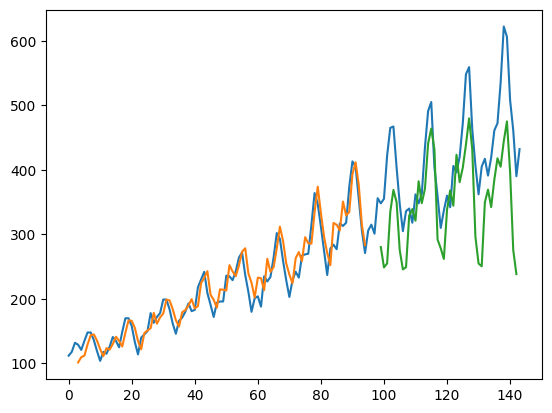

In [6]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

tf.random.set_seed(7)

dataframe = pandas.read_csv('airline-passengers.csv', usecols=[1], engine="python")
dataset = dataframe.values
dataset = dataset.astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)


# split into training and test set data
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))


def create_dataset(dataset, look_back=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return np.array(dataX), np.array(dataY)


look_back = 3
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

batch_size = 1
model = Sequential()
model.add(Input(batch_shape=(batch_size, look_back, 1)))
model.add(LSTM(4, stateful=True))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
for i in range(100):
	model.fit(trainX, trainY, epochs=1, batch_size=batch_size, verbose=2, shuffle=False)
	model.layers[0].reset_states()

trainPredict = model.predict(trainX, batch_size=batch_size)
model.layers[0].reset_states()
testPredict = model.predict(testX, batch_size=batch_size)
# Inverse predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculating RMS error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:, 0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:, 0]))
print('Test Score: %.2f RMSE' % (testScore))


# shifting train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[loop_back:len(trainPredict)+loop_back, :] = trainPredict
# shifting test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(loop_back*2)+1:len(dataset)-1, :] = testPredict
# plotting it
plt.plot(scaler.inverse_transform(dataset))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

